# Notebook 3: Build Filtered National Road Networks

## Objectives

This notebook generalizes the Ontario National Road Network (NRN) filtering workflow to all provincial and territorial NRN road segment layers.

Two nested road network representations are constructed for each province and territory:

1. **Backbone network**
    - Freeway
    - Expressway / Highway
    - Ramp

2. **Freight-access network**
    - Freeway
    - Expressway / Highway
    - Ramp
    - Arterial

The purpose of these filters is to reduce graph size prior to graph construction while preserving the major transportation corridors required for national-scale energy and industrial systems modelling.

This notebook produces:

- filtered provincial road networks
- concatenated national road networks
- summary tables comparing retained road segments by province and territory

The resulting GeoDataFrames will serve as inputs to subsequent notebooks for:

- Canada-wide network assembly
- graph construction
- graph simplification
- region-to-region connectivity
- TEMOA encoding

In [14]:
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import sqlite3
import pyogrio
from collections.abc import Sequence
from collections.abc import Mapping


# Raw National Road Network data directory
RAW_NRN = Path("../data_files/raw/nrn")

# Processed NRN output directory
PROCESSED_NRN = Path("../data_files/processed/nrn")
PROCESSED_NRN.mkdir(parents=True, exist_ok=True)

# Province and territory abbreviations used in the preprocessing workflow
PROVINCES = [
    "AB", "BC", "MB", "NB", "NL", "NS",
    "NT", "NU", "ON", "PE", "QC", "SK", "YT",
]

# Final output CRS for mapping and downstream model integration.
# Source CRS should be checked from each NRN layer before conversion.
WGS84_CRS = "EPSG:4326"

In [2]:
# Define nested road network representations.
#
# Backbone network:
# Long-distance freight corridors consisting of freeways, highways,
# and ramps.
#
# Freight-access network:
# Backbone network plus arterial roads to improve connectivity to
# industrial sites, ports, terminals, and regional centroids.

BACKBONE_CLASSES = (
    "Freeway",
    "Expressway / Highway",
    "Ramp",
)

FREIGHT_ACCESS_CLASSES = BACKBONE_CLASSES + (
    "Arterial",
)

In [3]:
def get_nrn_gpkg_path(province: str) -> Path:
    """
    Return the English NRN GeoPackage path for a province or territory.

    Parameters
    ----------
    province : str
        Two-letter province or territory abbreviation.

    Returns
    -------
    Path
        Path to the English NRN GeoPackage.

    Raises
    ------
    FileNotFoundError
        If the province directory or GeoPackage is missing.
    ValueError
        If multiple English GeoPackages are found.
    """
    province = province.upper()
    province_dir = RAW_NRN / province

    if not province_dir.is_dir():
        
        raise FileNotFoundError(
            f"No directory found for {province} at {province_dir}. "
            f"Check RAW_NRN and that the data has been downloaded."
        )

    matches = list(province_dir.glob("*_en.gpkg"))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Directory {province_dir} exists but contains no "
            f"'*_en.gpkg' file."
        )

    if len(matches) > 1:
        raise ValueError(
            f"Expected exactly one English GPKG file for {province}, "
            f"found {len(matches)}: {[m.name for m in matches]}"
        )

    return matches[0]


In [4]:
# Read the contents of a GeoPackage into a DataFrame.

def get_gpkg_contents(gpkg_path: Path) -> pd.DataFrame:
    """
    Return the GeoPackage contents table.

    Args:
        gpkg_path:
            Path to a GeoPackage file. Must already exist; sqlite3 will
            silently create an empty file at this path otherwise.

    Returns:
        GeoPackage contents table as a DataFrame.
    """

    if not gpkg_path.exists():
        raise FileNotFoundError(
            f"GeoPackage not found at {gpkg_path}."
        )

    with sqlite3.connect(gpkg_path) as conn:
        contents = pd.read_sql_query(
            """
            SELECT *
            FROM gpkg_contents
            """,
            conn,
        )

    return contents

In [5]:
# Remove duplicate-geometry rows introduced by concatenating road networks
# across provincial or territorial boundaries.

def deduplicate_boundary_segments(
    gdf: gpd.GeoDataFrame,
    priority_classes: Sequence[str]
) -> gpd.GeoDataFrame:
    """
    Remove duplicate-geometry rows introduced by concatenating road
    networks across provincial or territorial boundaries.

    Adjacent provinces' NRN extracts can each independently digitize and
    classify the same physical boundary-crossing segment, producing
    identical geometries with disagreeing ROADCLASS values once
    concatenated. Keeps one row per unique geometry, preferring whichever
    classification appears earliest in priority_classes.

    Args:
        gdf:
            Concatenated, multi-province road network GeoDataFrame.
            Must contain a ROADCLASS column.
        priority_classes:
            ROADCLASS values in priority order, highest priority first.
            Any class not listed is treated as lowest priority.

    Returns:
        gdf with duplicate geometries removed, index reset.
    """

    priority = {cls: i for i, cls in enumerate(priority_classes)}
    default_priority = len(priority_classes)

    working = gdf.copy()
    working["_priority"] = (
        working["ROADCLASS"].map(priority).fillna(default_priority)
    )
    working["_geom_wkt"] = working.geometry.apply(lambda g: g.wkt)

    deduped = (
        working
        .sort_values("_priority")
        .drop_duplicates(subset="_geom_wkt", keep="first")
        .drop(columns=["_priority", "_geom_wkt"])
        .reset_index(drop=True)
    )

    return deduped

In [6]:
# Determine the ROADSEG table name within a province's GeoPackage.
# Table names contain version numbers and therefore cannot be hardcoded.

def get_roadseg_table(gpkg_path: Path) -> str:
    """
    Return the ROADSEG table name contained in a provincial GeoPackage.

    Args:
        gpkg_path:
            Path to the provincial NRN GeoPackage.

    Returns:
        Name of the ROADSEG table.
    """

    contents = get_gpkg_contents(gpkg_path)

    matches = contents[
        contents["table_name"].str.endswith("_ROADSEG")
    ]["table_name"].tolist()

    if len(matches) == 0:
        raise ValueError(
            f"No ROADSEG table found in {gpkg_path.name}. "
            f"Available tables: {contents['table_name'].tolist()}"
        )

    if len(matches) > 1:
        raise ValueError(
            f"Expected exactly one ROADSEG table in {gpkg_path.name}, "
            f"found {len(matches)}: {matches}"
        )

    return matches[0]

In [7]:
# Determine the ROADCLASS breakdown for a province's road segments via a
# single grouped SQL query rather than materializing all geometries in memory.

def get_roadclass_counts(gpkg_path: Path, roadseg_table: str) -> pd.DataFrame:
    """
    Return per-ROADCLASS segment counts for a provincial GeoPackage.
    """

    query = f"""
        SELECT ROADCLASS,
               COUNT(*) AS segments
        FROM "{roadseg_table}"
        GROUP BY ROADCLASS
        ORDER BY segments DESC;
    """

    with sqlite3.connect(gpkg_path) as conn:
        counts = pd.read_sql_query(query, conn)

    return counts


freight_access_where = (
    "ROADCLASS IN ("
    + ", ".join(repr(cls) for cls in FREIGHT_ACCESS_CLASSES)
    + ")"
)

provincial_freight_access = {}
provincial_backbone = {}
provincial_roadclass_counts = []
provincial_crs = {}

for province in PROVINCES:

    gpkg_path = get_nrn_gpkg_path(province)
    roadseg_table = get_roadseg_table(gpkg_path)

    roadclass_counts = get_roadclass_counts(gpkg_path, roadseg_table)
    roadclass_counts.insert(0, "province", province)
    provincial_roadclass_counts.append(roadclass_counts)

    full_count = roadclass_counts["segments"].sum()

    freight_access = gpd.read_file(
        gpkg_path,
        layer=roadseg_table,
        where=freight_access_where,
    )

    freight_access["province"] = province

    backbone = freight_access[
        freight_access["ROADCLASS"].isin(BACKBONE_CLASSES)
    ].copy()

    provincial_freight_access[province] = freight_access
    provincial_backbone[province] = backbone
    provincial_crs[province] = freight_access.crs

    print(
        f"{province}: "
        f"{full_count:,} total | "
        f"{len(backbone):,} backbone | "
        f"{len(freight_access):,} freight-access"
    )

roadclass_counts_all = pd.concat(
    provincial_roadclass_counts,
    ignore_index=True,
)

if any(crs is None for crs in provincial_crs.values()):
    raise ValueError(
        f"Some provincial GeoPackages have missing CRS: "
        f"{[p for p, c in provincial_crs.items() if c is None]}"
    )

unique_crs = {crs.to_string() for crs in provincial_crs.values()}

if len(unique_crs) != 1:
    raise ValueError(
        f"Provincial GeoPackages do not share a common CRS: "
        f"{ {p: c.to_string() for p, c in provincial_crs.items()} }"
    )

print(f"\nAll provinces share CRS: {unique_crs.pop()}")

AB: 443,593 total | 20,643 backbone | 49,563 freight-access
BC: 263,584 total | 15,270 backbone | 34,193 freight-access
MB: 110,604 total | 22,365 backbone | 22,367 freight-access
NB: 69,714 total | 5,129 backbone | 5,570 freight-access
NL: 44,484 total | 8,436 backbone | 8,455 freight-access
NS: 119,846 total | 4,362 backbone | 11,919 freight-access
NT: 8,540 total | 984 backbone | 984 freight-access
NU: 5,137 total | 0 backbone | 0 freight-access
ON: 651,662 total | 26,964 backbone | 123,799 freight-access
PE: 19,465 total | 340 backbone | 1,612 freight-access
QC: 440,398 total | 39,430 backbone | 73,259 freight-access
SK: 299,124 total | 21,315 backbone | 21,331 freight-access
YT: 7,384 total | 2,022 backbone | 2,548 freight-access

All provinces share CRS: EPSG:4617


In [8]:
# Construct national road network representations.

WGS84_CRS = "EPSG:4326"
source_crs = provincial_crs[PROVINCES[0]]

canada_backbone_raw = gpd.GeoDataFrame(
    pd.concat(provincial_backbone.values(), ignore_index=True),
    geometry="geometry",
    crs=source_crs,
)

canada_freight_access_raw = gpd.GeoDataFrame(
    pd.concat(provincial_freight_access.values(), ignore_index=True),
    geometry="geometry",
    crs=source_crs,
)

canada_backbone = deduplicate_boundary_segments(
    canada_backbone_raw,
    BACKBONE_CLASSES,
).to_crs(WGS84_CRS)

canada_freight_access = deduplicate_boundary_segments(
    canada_freight_access_raw,
    FREIGHT_ACCESS_CLASSES,
).to_crs(WGS84_CRS)

print(
    f"National backbone network: "
    f"{canada_backbone.shape[0]:,} segments "
    f"(CRS: {canada_backbone.crs})"
)

print(
    f"National freight-access network: "
    f"{canada_freight_access.shape[0]:,} segments "
    f"(CRS: {canada_freight_access.crs})"
)

National backbone network: 167,260 segments (CRS: EPSG:4326)
National freight-access network: 355,565 segments (CRS: EPSG:4326)


In [9]:
def validate_road_network(gdf: gpd.GeoDataFrame, name: str) -> None:
    """
    Run geometry sanity checks on a road network GeoDataFrame.
    """

    print(f"--- {name} ---")

    geom = gdf.geometry
    non_null_geom = geom.dropna()

    null_geom = geom.isna().sum()
    empty_geom = non_null_geom.is_empty.sum()
    invalid_geom = (~non_null_geom.is_valid).sum()
    duplicate_geom = non_null_geom.apply(lambda g: g.wkt).duplicated().sum()

    print(f"Null geometries: {null_geom:,}")
    print(f"Empty geometries: {empty_geom:,}")
    print(f"Invalid geometries: {invalid_geom:,}")
    print(f"Duplicate geometries (identical WKT): {duplicate_geom:,}")
    print()

validate_road_network(canada_backbone, "Backbone")
validate_road_network(canada_freight_access, "Freight-access")

--- Backbone ---
Null geometries: 0
Empty geometries: 0
Invalid geometries: 0
Duplicate geometries (identical WKT): 0

--- Freight-access ---
Null geometries: 0
Empty geometries: 0
Invalid geometries: 0
Duplicate geometries (identical WKT): 0



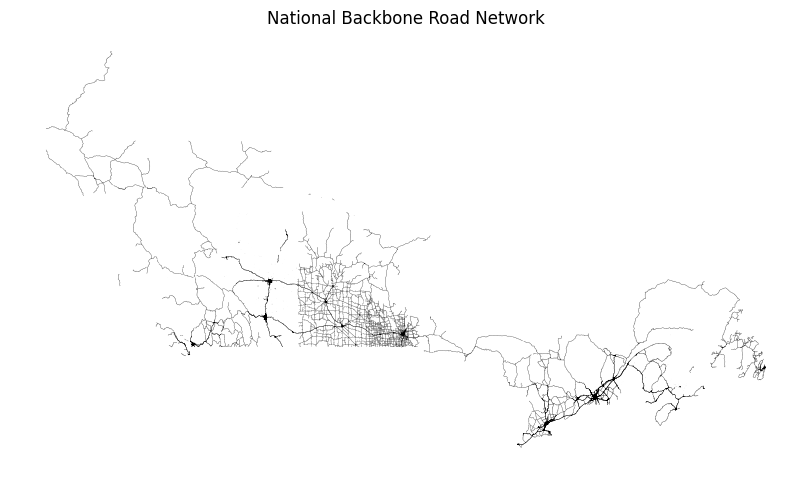

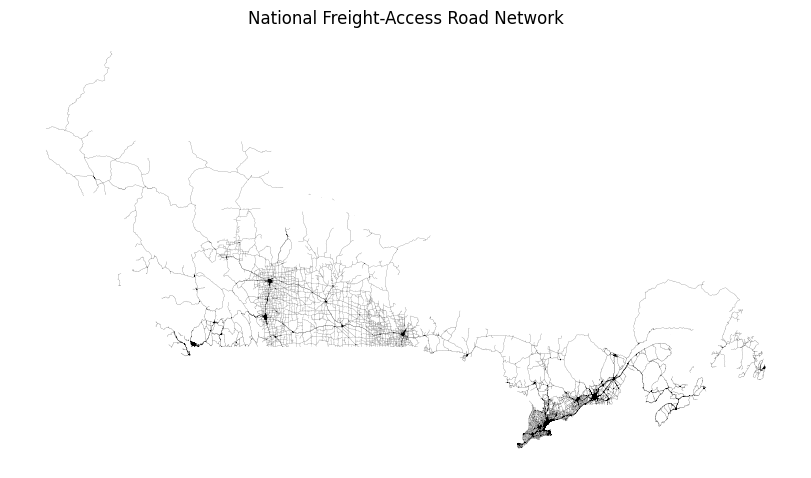

In [10]:
# Plot the national backbone network.

def plot_network(
    gdf: gpd.GeoDataFrame,
    title: str,
    linewidth: float = 0.2,
):
    fig, ax = plt.subplots(
        figsize=(8, 8),
        constrained_layout=True,
    )

    gdf.plot(
        ax=ax,
        linewidth=linewidth,
        color="black",
    )

    ax.set_title(title)
    ax.set_axis_off()

    plt.show()

plot_network(
    canada_backbone,
    "National Backbone Road Network",
)

plot_network(
    canada_freight_access,
    "National Freight-Access Road Network",
    linewidth=0.1,
)

In [11]:
summary_rows = []

for province in PROVINCES:

    full_segments = int(
        roadclass_counts_all.loc[
            roadclass_counts_all["province"] == province,
            "segments",
        ].sum()
    )

    backbone_segments = int(
        (canada_backbone["province"] == province).sum()
    )

    freight_access_segments = int(
        (canada_freight_access["province"] == province).sum()
    )

    arterial_segments = int(
    (
        (canada_freight_access["province"] == province)
        & (canada_freight_access["ROADCLASS"] == "Arterial")
    ).sum()
    )

    summary_rows.append(
        {
            "province": province,
            "full_segments": full_segments,
            "backbone_segments": backbone_segments,
            "arterial_segments": arterial_segments,
            "freight_access_segments": freight_access_segments,
            "backbone_percent": round(
                100 * backbone_segments / full_segments, 1
            ) if full_segments else 0.0,
            "arterial_percent": round(
                100 * arterial_segments / full_segments, 1
            ) if full_segments else 0.0,
            "freight_access_percent": round(
                100 * freight_access_segments / full_segments, 1
            ) if full_segments else 0.0,
        }
    )

national_row = {
    "province": "Canada",
    "full_segments": sum(r["full_segments"] for r in summary_rows),
    "backbone_segments": sum(r["backbone_segments"] for r in summary_rows),
    "arterial_segments": sum(r["arterial_segments"] for r in summary_rows),
    "freight_access_segments": sum(
        r["freight_access_segments"] for r in summary_rows
    ),
}

national_row["backbone_percent"] = round(
    100 * national_row["backbone_segments"] / national_row["full_segments"], 1
)
national_row["arterial_percent"] = round(
    100 * national_row["arterial_segments"] / national_row["full_segments"], 1
)
national_row["freight_access_percent"] = round(
    100 * national_row["freight_access_segments"] / national_row["full_segments"], 1
)

summary_rows.append(national_row)

network_summary = pd.DataFrame(summary_rows)

network_summary.style.format(
    {
        "backbone_percent": "{:.1f}%",
        "arterial_percent": "{:.1f}%",
        "freight_access_percent": "{:.1f}%",
    }
)

,province,full_segments,backbone_segments,arterial_segments,freight_access_segments,backbone_percent,arterial_percent,freight_access_percent
0,AB,443593,20643,28885,49528,4.7%,6.5%,11.2%
1,BC,263584,15270,18923,34193,5.8%,7.2%,13.0%
2,MB,110604,22365,2,22367,20.2%,0.0%,20.2%
3,NB,69714,5129,441,5570,7.4%,0.6%,8.0%
4,NL,44484,8436,19,8455,19.0%,0.0%,19.0%
5,NS,119846,4362,7557,11919,3.6%,6.3%,9.9%
6,NT,8540,984,0,984,11.5%,0.0%,11.5%
7,NU,5137,0,0,0,0.0%,0.0%,0.0%
8,ON,651662,26964,96835,123799,4.1%,14.9%,19.0%
9,PE,19465,340,1272,1612,1.7%,6.5%,8.3%


In [12]:
roadclass_counts_all.pivot(
    index="province",
    columns="ROADCLASS",
    values="segments",
).fillna(0)

ROADCLASS,Alleyway / Lane,Arterial,Collector,Expressway / Highway,Freeway,Local / Strata,Local / Street,Local / Unknown,Ramp,Rapid Transit,Resource / Recreation,Service Lane,Unknown,Winter
province,,,,,,,,,,,,,,
AB,201.0,28920.0,170670.0,7344.0,170.0,12074.0,162403.0,1208.0,13129.0,110.0,46188.0,1136.0,0.0,40.0
BC,12084.0,18923.0,30309.0,9741.0,1843.0,15179.0,157655.0,3701.0,3686.0,0.0,6873.0,3590.0,0.0,0.0
MB,0.0,2.0,44939.0,20857.0,59.0,244.0,42902.0,0.0,1449.0,7.0,12.0,57.0,0.0,76.0
NB,7.0,441.0,6626.0,2031.0,1168.0,10.0,44939.0,8700.0,1930.0,0.0,3638.0,205.0,19.0,0.0
NL,4.0,19.0,12984.0,7247.0,465.0,108.0,22774.0,87.0,724.0,0.0,63.0,9.0,0.0,0.0
NS,0.0,7557.0,6910.0,1845.0,1038.0,0.0,68736.0,0.0,1479.0,0.0,31879.0,324.0,78.0,0.0
NT,223.0,0.0,0.0,981.0,0.0,0.0,0.0,5377.0,3.0,0.0,1219.0,55.0,344.0,338.0
NU,0.0,0.0,135.0,0.0,0.0,0.0,252.0,30.0,0.0,0.0,0.0,67.0,4653.0,0.0
ON,6904.0,96835.0,53480.0,12510.0,6903.0,61875.0,357511.0,850.0,7551.0,558.0,45681.0,767.0,3.0,234.0


In [15]:
# Plot provincial and territorial road networks as subplot panels.

def plot_provincial_networks(
    provincial_networks: Mapping[str, gpd.GeoDataFrame],
    title: str,
    linewidth: float = 0.2,
) -> None:
    """
    Plot provincial and territorial road networks as a subplot grid.

    Args:
        provincial_networks:
            Mapping from province or territory abbreviations to
            GeoDataFrames.
        title:
            Figure title.
        linewidth:
            Width of plotted road segment lines.
    """

    n_cols = 4
    n_rows = 4

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(14, 14),
        constrained_layout=True,
    )

    axes = axes.flatten()

    for index, province in enumerate(PROVINCES):

        ax = axes[index]
        roads = provincial_networks[province]

        if not roads.empty:
            roads.plot(
                ax=ax,
                linewidth=linewidth,
                color="black",
            )

        ax.set_title(province)
        ax.set_axis_off()

    # Hide unused subplot panels.
    for ax in axes[len(PROVINCES):]:
        ax.set_visible(False)

    fig.suptitle(
        title,
        fontsize=16,
        y=1.02,
    )

    plt.show()

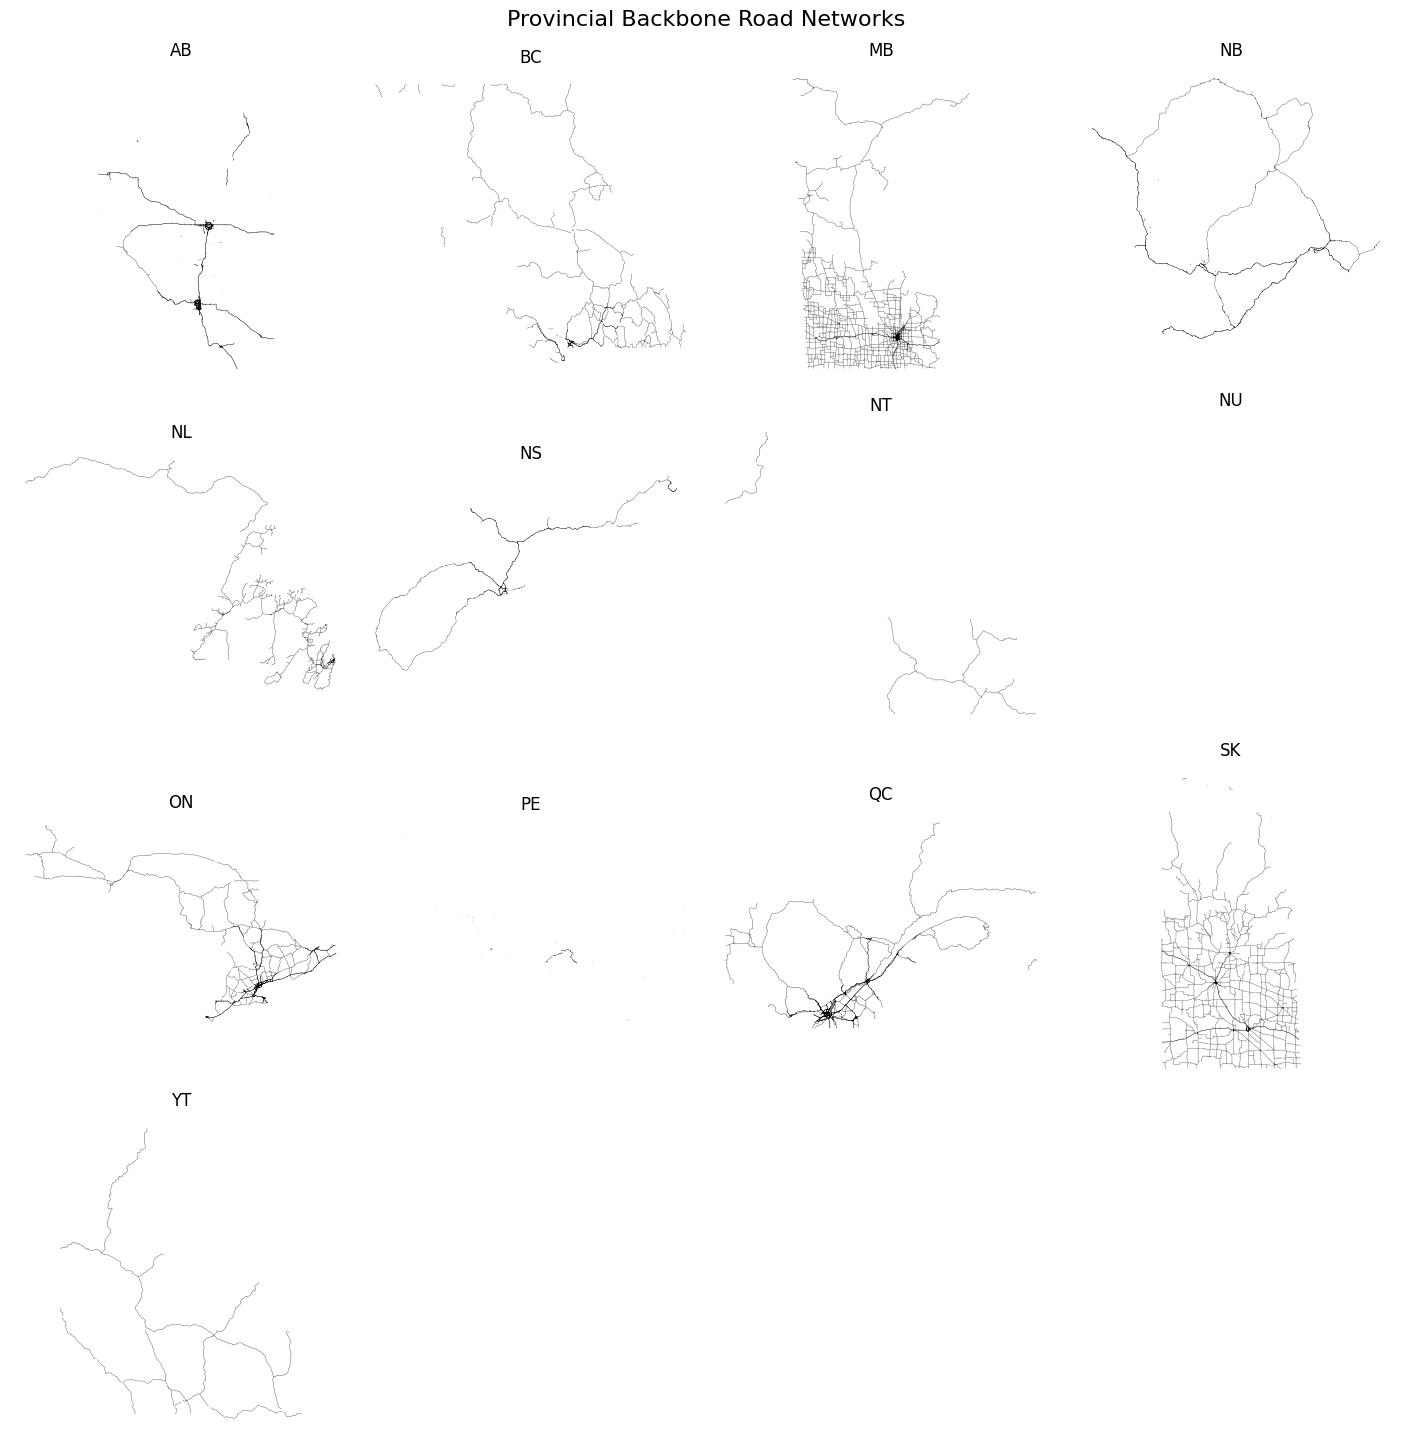

In [16]:
plot_provincial_networks(
    provincial_backbone,
    "Provincial Backbone Road Networks",
    linewidth=0.2,
)

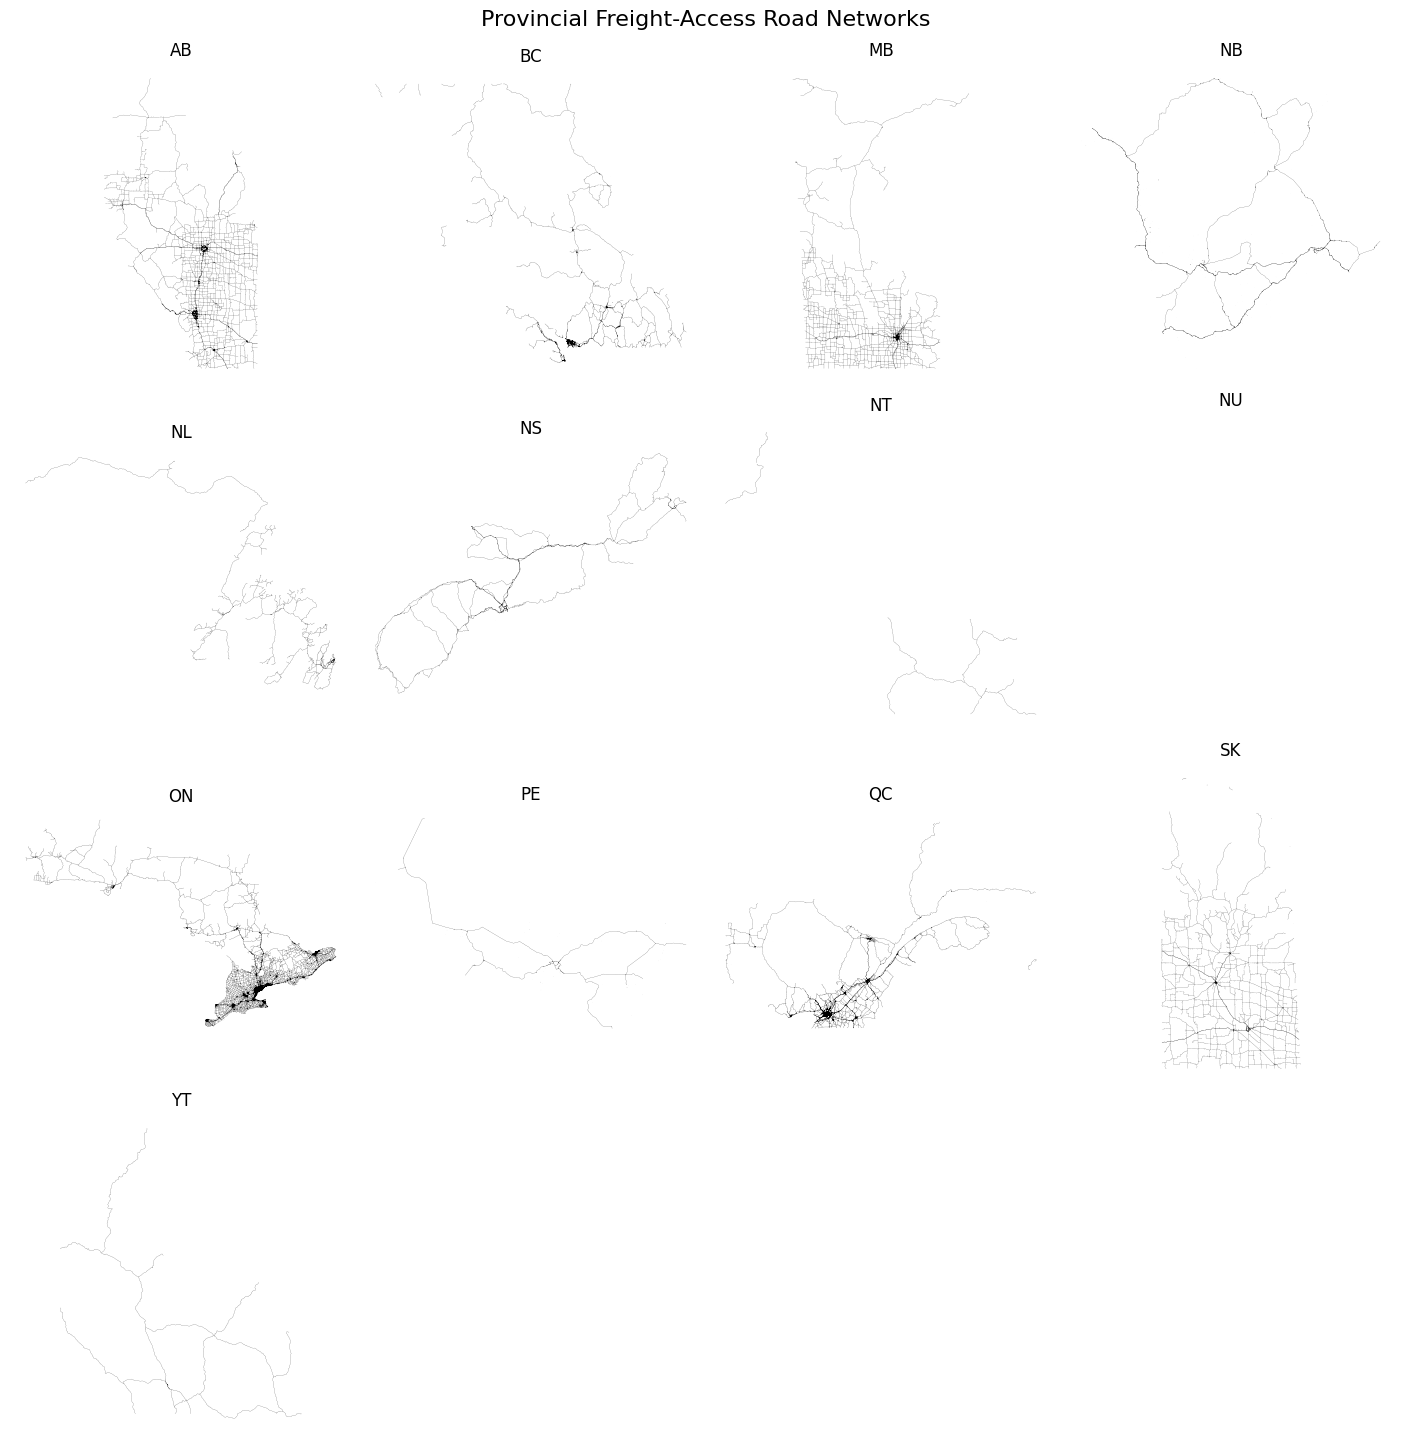

In [17]:
plot_provincial_networks(
    provincial_freight_access,
    "Provincial Freight-Access Road Networks",
    linewidth=0.1,
)

In [18]:
# Export provincial and territorial filtered road networks.

for province in PROVINCES:

    output_path = (
        PROCESSED_NRN /
        f"{province}_filtered_road_networks.gpkg"
    )

    if output_path.exists():
        output_path.unlink()

    provincial_backbone[province].to_file(
        output_path,
        layer="backbone",
        driver="GPKG",
    )

    provincial_freight_access[province].to_file(
        output_path,
        layer="freight_access",
        driver="GPKG",
    )

    print(f"{province}: exported {output_path.name}")
    print(
    f"{province}: "
    f"{len(provincial_backbone[province]):,} backbone | "
    f"{len(provincial_freight_access[province]):,} freight-access "
    f"→ {output_path.name}"
)

AB: exported AB_filtered_road_networks.gpkg
AB: 20,643 backbone | 49,563 freight-access → AB_filtered_road_networks.gpkg
BC: exported BC_filtered_road_networks.gpkg
BC: 15,270 backbone | 34,193 freight-access → BC_filtered_road_networks.gpkg
MB: exported MB_filtered_road_networks.gpkg
MB: 22,365 backbone | 22,367 freight-access → MB_filtered_road_networks.gpkg
NB: exported NB_filtered_road_networks.gpkg
NB: 5,129 backbone | 5,570 freight-access → NB_filtered_road_networks.gpkg
NL: exported NL_filtered_road_networks.gpkg
NL: 8,436 backbone | 8,455 freight-access → NL_filtered_road_networks.gpkg
NS: exported NS_filtered_road_networks.gpkg
NS: 4,362 backbone | 11,919 freight-access → NS_filtered_road_networks.gpkg
NT: exported NT_filtered_road_networks.gpkg
NT: 984 backbone | 984 freight-access → NT_filtered_road_networks.gpkg
NU: exported NU_filtered_road_networks.gpkg
NU: 0 backbone | 0 freight-access → NU_filtered_road_networks.gpkg
ON: exported ON_filtered_road_networks.gpkg
ON: 26,96

In [19]:
# Export national filtered road networks.

canada_output_path = (
    PROCESSED_NRN /
    "CANADA_filtered_road_networks.gpkg"
)

if canada_output_path.exists():
    canada_output_path.unlink()

canada_backbone.to_file(
    canada_output_path,
    layer="backbone",
    driver="GPKG",
)

canada_freight_access.to_file(
    canada_output_path,
    layer="freight_access",
    driver="GPKG",
)

print(
    f"Canada: exported "
    f"{canada_output_path.name}"
)
print(
    f"Canada: "
    f"{len(canada_backbone):,} backbone | "
    f"{len(canada_freight_access):,} freight-access "
    f"→ {canada_output_path.name}"
)

Canada: exported CANADA_filtered_road_networks.gpkg
Canada: 167,260 backbone | 355,565 freight-access → CANADA_filtered_road_networks.gpkg


In [20]:
# Export network summary table.

summary_output_path = (
    PROCESSED_NRN /
    "filtered_road_network_summary.csv"
)

network_summary.to_csv(
    summary_output_path,
    index=False,
)

print(
    f"Exported network summary table → "
    f"{summary_output_path.name}"
)

Exported network summary table → filtered_road_network_summary.csv
